In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('./wildfire_cls_train_full.csv', delimiter=',')
data.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [2]:
data.describe()


,latitude,longitude,acq_time,year,month,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,4340.000000,4340.000000,4340.000000,4340.000000,3924.000000,4013.000000,4340.000000,4133.000000,4340.000000,4340.000000
mean,9.821703,29.430626,1177.046774,2024.501843,7.240316,336.677742,35.082627,17.508033,2.597111,37.924378
std,24.321271,78.842700,683.844117,0.500054,2.791615,18.539217,5.821218,17.051980,3.062512,18.731153
min,-42.988300,-167.990600,0.000000,2024.000000,1.000000,290.000000,17.700000,0.000000,0.000000,5.000000
25%,-8.611625,-40.980600,602.000000,2024.000000,5.000000,324.860000,31.000000,5.100000,0.600000,24.200000
50%,10.268500,34.833700,1208.000000,2025.000000,8.000000,335.530000,35.100000,12.400000,1.540000,36.200000
75%,29.011025,95.166775,1752.000000,2025.000000,9.000000,346.990000,39.125000,24.000000,3.370000,50.500000
max,69.930900,153.754900,2359.000000,2025.000000,12.000000,503.710000,54.100000,130.700000,23.690000,95.000000


In [3]:
pd.isna(data).sum()

latitude            0
longitude           0
acq_date            0
acq_time            0
year                0
month             416
season              0
daynight            0
region              0
country             0
fire_type           0
satellite           0
instrument          0
brightness_k      327
confidence          0
temp_max_c          0
wind_max_kmh      207
precip_mm           0
humidity_pct        0
fire_intensity      0
dtype: int64

NaN values = 
month = 416
brightness_k = 327
wind_max_kmh = 207
concerning...

In [4]:
missing = pd.DataFrame({
  "count": data.isna().sum(),
  "percent": data.isna().mean() * 100
})
missing[missing["count"] > 0]

,count,percent
month,416,9.585253
brightness_k,327,7.534562
wind_max_kmh,207,4.769585


percentage of NaN is too high for my liking.

In [5]:
data.loc[data["month"].isna(), ["acq_date", "month"]].head(20)
date_month = pd.to_datetime(data["acq_date"]).dt.month
(data.loc[data["month"].notna(), "month"] !=
 date_month[data["month"].notna()]).sum()


np.int64(0)

In [6]:
data["acq_date"] = pd.to_datetime(data["acq_date"])
data.loc[data["month"].isna(), "month"] = (
  data.loc[data["month"].isna(), "acq_date"].dt.month
)
data["month"].isna().sum()

np.int64(0)

cool the months were just in a crappy format, let's check brightness_k and wind_max_khm now

In [7]:
data[["brightness_k", "wind_max_kmh"]].describe()



,brightness_k,wind_max_kmh
count,4013.000000,4133.000000
mean,336.677742,17.508033
std,18.539217,17.051980
min,290.000000,0.000000
25%,324.860000,5.100000
50%,335.530000,12.400000
75%,346.990000,24.000000
max,503.710000,130.700000


<Axes: >

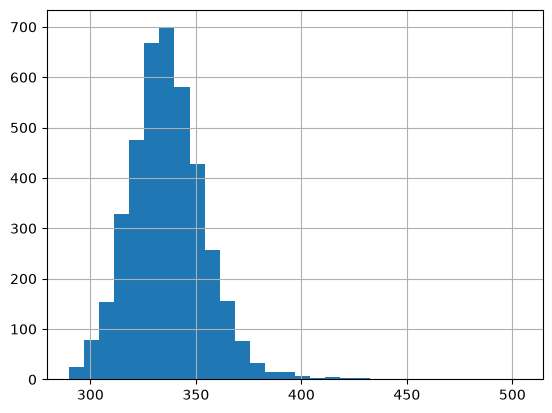

In [8]:
data["brightness_k"].hist(bins=30)

<Axes: >

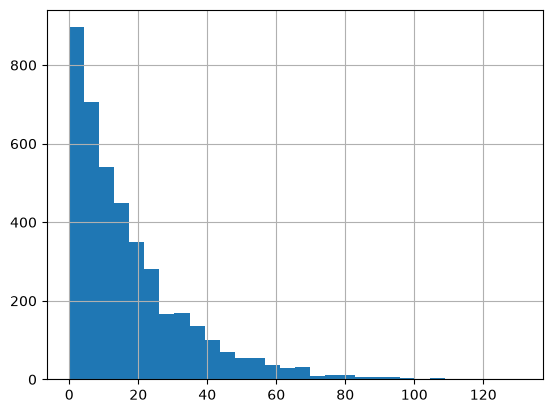

In [9]:
data["wind_max_kmh"].hist(bins=30)

In [10]:
data.groupby("region")[["brightness_k", "wind_max_kmh"]].agg(
    lambda x: x.isna().mean() * 100
)

,brightness_k,wind_max_kmh
region,,
Australia,8.000000,4.727273
Mediterranean,9.054326,6.438632
North_America,6.807512,5.633803
South_America,7.392996,4.798962
South_Asia,6.927374,3.687151
Southeast_Asia,7.884363,4.599212
Sub_Saharan_Africa,7.272727,4.615385


In [11]:
data.groupby("satellite")[["brightness_k", "wind_max_kmh"]].agg(
    lambda x: x.isna().mean() * 100
)

,brightness_k,wind_max_kmh
satellite,,
AQUA,7.783883,4.578755
NOAA-20,7.208029,5.383212
Suomi-NPP,7.420814,3.710407
TERRA,7.736390,5.444126


In [12]:
data.groupby("instrument")[["brightness_k", "wind_max_kmh"]].agg(
    lambda x: x.isna().mean() * 100
)

,brightness_k,wind_max_kmh
instrument,,
MODIS,7.760636,5.002338
VIIRS,7.314857,4.543389


In [13]:
pd.crosstab(
    data["brightness_k"].isna(),
    data["fire_intensity"],
    normalize="index"
) * 100

fire_intensity,Extreme,High,Low,Moderate
brightness_k,,,,
False,8.821331,30.600548,16.222278,44.355844
True,8.256881,34.250765,14.373089,43.119266


In [14]:
pd.crosstab(
    data["wind_max_kmh"].isna(),
    data["fire_intensity"],
    normalize="index"
) * 100

fire_intensity,Extreme,High,Low,Moderate
wind_max_kmh,,,,
False,8.613598,31.018631,16.090007,44.277764
True,12.077295,28.019324,15.942029,43.961353


In [15]:
data["fire_intensity"].value_counts()

fire_intensity
Moderate    1921
High        1340
Low          698
Extreme      381
Name: count, dtype: int64

In [16]:
data["fire_intensity"].value_counts(normalize=True) * 100


fire_intensity
Moderate    44.262673
High        30.875576
Low         16.082949
Extreme      8.778802
Name: proportion, dtype: float64

<Axes: xlabel='fire_intensity'>

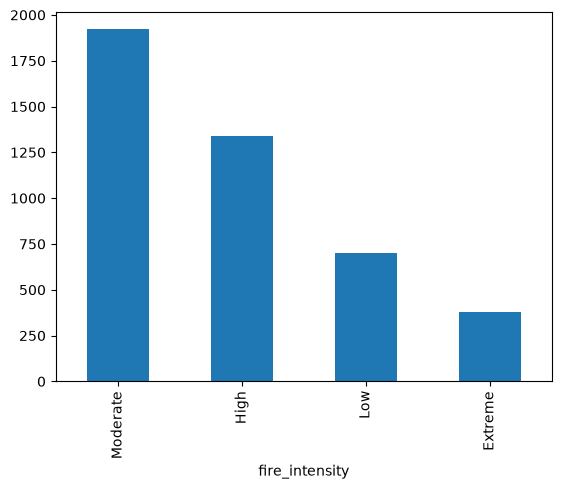

In [17]:
data["fire_intensity"].value_counts().plot(kind="bar")

Target variable is moderately imbalanced, "Moderate" is 44.3% of observations while "Extreme" is only 8.8%. Overall accuracy will be considered alongside class-sensitive metrics such as macro-F1 and confusion matrix to ensure performance on minority classes is not obscured by larger classes.

In [18]:
numeric_data = data.select_dtypes(include="number")
numeric_data.columns
numeric_data.corr()

,latitude,longitude,acq_time,year,month,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
latitude,1.000000,-0.162653,-0.016648,0.016765,-0.053601,-0.003897,0.057751,-0.016326,0.008045,-0.028769
longitude,-0.162653,1.000000,0.005183,0.022066,-0.284750,-0.094968,-0.158327,0.026428,0.176069,0.462007
acq_time,-0.016648,0.005183,1.000000,-0.003629,0.000829,0.036044,-0.002655,0.034678,0.008094,-0.002623
year,0.016765,0.022066,-0.003629,1.000000,0.001097,0.013378,0.036890,-0.011904,-0.015466,0.007842
month,-0.053601,-0.284750,0.000829,0.001097,1.000000,0.028388,0.475942,-0.010383,-0.084460,-0.204895
brightness_k,-0.003897,-0.094968,0.036044,0.013378,0.028388,1.000000,0.049028,-0.020866,-0.009681,-0.050409
temp_max_c,0.057751,-0.158327,-0.002655,0.036890,0.475942,0.049028,1.000000,0.005850,-0.117732,-0.263318
wind_max_kmh,-0.016326,0.026428,0.034678,-0.011904,-0.010383,-0.020866,0.005850,1.000000,0.013134,0.017510
precip_mm,0.008045,0.176069,0.008094,-0.015466,-0.084460,-0.009681,-0.117732,0.013134,1.000000,0.347163
humidity_pct,-0.028769,0.462007,-0.002623,0.007842,-0.204895,-0.050409,-0.263318,0.017510,0.347163,1.000000


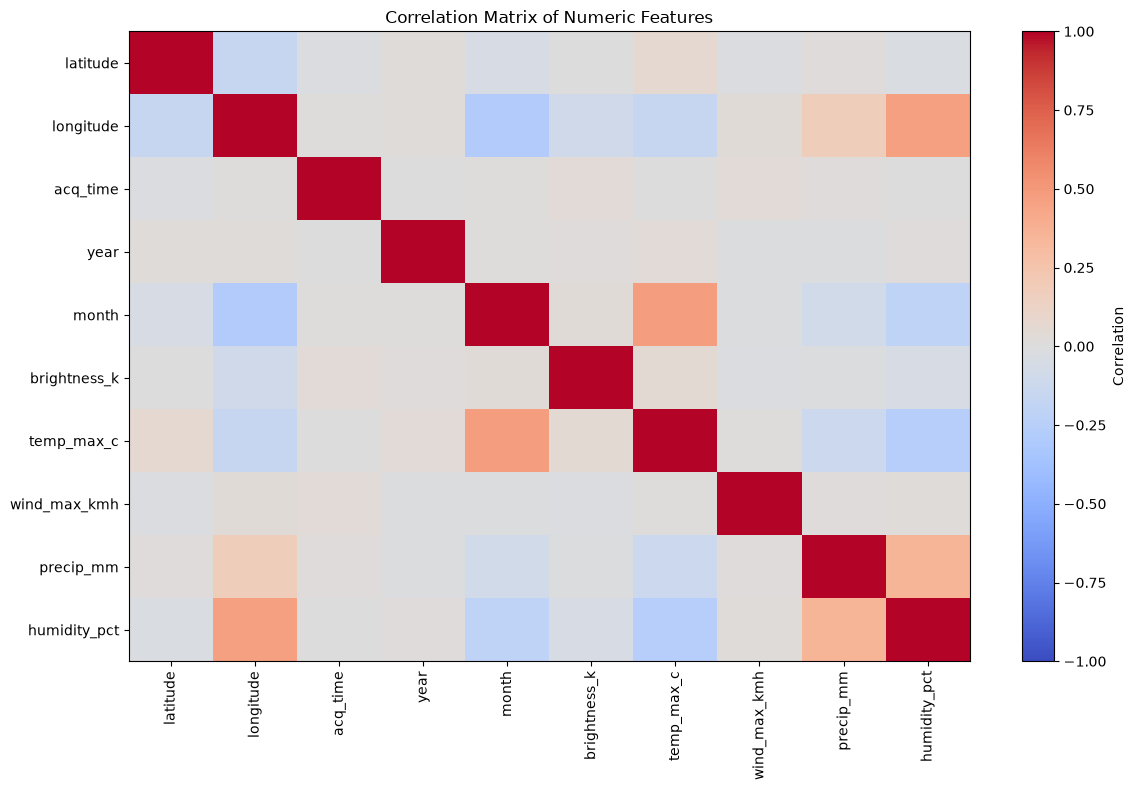

In [19]:
import matplotlib.pyplot as plt
corr = numeric_data.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

In [20]:
corr.unstack().sort_values(ascending=False).drop_duplicates()

latitude      latitude        1.000000
month         temp_max_c      0.475942
longitude     humidity_pct    0.462007
precip_mm     humidity_pct    0.347163
              longitude       0.176069
latitude      temp_max_c      0.057751
brightness_k  temp_max_c      0.049028
year          temp_max_c      0.036890
brightness_k  acq_time        0.036044
acq_time      wind_max_kmh    0.034678
month         brightness_k    0.028388
wind_max_kmh  longitude       0.026428
year          longitude       0.022066
humidity_pct  wind_max_kmh    0.017510
year          latitude        0.016765
brightness_k  year            0.013378
wind_max_kmh  precip_mm       0.013134
acq_time      precip_mm       0.008094
precip_mm     latitude        0.008045
year          humidity_pct    0.007842
wind_max_kmh  temp_max_c      0.005850
longitude     acq_time        0.005183
year          month           0.001097
month         acq_time        0.000829
acq_time      humidity_pct   -0.002623
temp_max_c    acq_time   

Numeric features showed several moderate correlations, with the strongest being between month and temp_max_c (r = 0.476), longitude and humidity_pct (r = 0.462), and precip_mm and humidity_pct (r = 0.347). No very strong correlations observed.

In [21]:
categorical_cols = data.select_dtypes(include="str").columns

for col in categorical_cols:
    print(f"{col}: {data[col].nunique()} unique values")
    print(data[col].value_counts())
    print()

season: 4 unique values
season
Spring    1333
Summer    1315
Winter     915
Autumn     777
Name: count, dtype: int64

daynight: 2 unique values
daynight
D    2392
N    1948
Name: count, dtype: int64

region: 7 unique values
region
South_Asia            895
South_America         771
Southeast_Asia        761
Sub_Saharan_Africa    715
Mediterranean         497
North_America         426
Australia             275
Name: count, dtype: int64

country: 35 unique values
country
Australia       275
Sri Lanka       202
India           187
Pakistan        174
Nepal           169
Bangladesh      163
Mexico          148
Venezuela       145
Canada          142
Vietnam         139
Brazil          138
Philippines     138
Colombia        137
USA             136
Thailand        133
Myanmar         130
Peru            127
Tanzania        116
Argentina       113
Malaysia        112
Bolivia         111
Indonesia       109
Mozambique      108
DRC             108
Zambia           98
South Africa     96
Nigeri

In [22]:
for col in categorical_cols:
    print(f"{col}: {data[col].nunique()} unique values")

season: 4 unique values
daynight: 2 unique values
region: 7 unique values
country: 35 unique values
fire_type: 10 unique values
satellite: 4 unique values
instrument: 2 unique values
confidence: 3 unique values
fire_intensity: 4 unique values


In [23]:
X = data.drop(columns=["fire_intensity", "acq_date"])
y = data["fire_intensity"]

In [24]:
data["brightness_k"] = data["brightness_k"].fillna(
    data["brightness_k"].mean()
)

data["wind_max_kmh"] = data["wind_max_kmh"].fillna(
    data["wind_max_kmh"].mean()
)

In [25]:
pd.isna(data).sum()

latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
fire_intensity    0
dtype: int64

In [26]:
X = data.drop(columns=["fire_intensity", "acq_date"])
y = data["fire_intensity"]

In [27]:
dataXExpand = pd.get_dummies(X)

dataXExpand.head()

,latitude,longitude,acq_time,year,month,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,...,fire_type_Wildfire,satellite_AQUA,satellite_NOAA-20,satellite_Suomi-NPP,satellite_TERRA,instrument_MODIS,instrument_VIIRS,confidence_high,confidence_low,confidence_nominal
0,-22.1967,-61.5275,1838,2024,8.0,360.26,40.6,39.000000,0.11,17.1,...,False,False,False,True,False,False,True,False,False,True
1,64.2205,-53.4116,424,2024,7.0,326.20,38.9,17.508033,0.06,13.2,...,False,False,False,True,False,False,True,True,False,False
2,38.6810,9.5739,546,2024,6.0,343.36,36.9,30.100000,0.19,35.2,...,True,True,False,False,False,True,False,True,False,False
3,68.1959,-90.3475,2240,2024,8.0,389.16,43.8,17.700000,0.98,32.8,...,False,False,False,False,True,True,False,False,False,True
4,0.6527,118.6227,2301,2025,8.0,335.68,34.8,1.000000,0.18,83.2,...,False,False,False,False,True,True,False,True,False,False


In [28]:
from sklearn.model_selection import train_test_split

train_val_X, test_data_X, train_val_y, test_data_y = train_test_split(
    dataXExpand, y, test_size=0.2, shuffle=True, random_state=0
)

train_data_X, val_data_X, train_data_y, val_data_y = train_test_split(
    train_val_X, train_val_y, test_size=0.25, shuffle=True, random_state=0
)

print(train_data_X.shape, val_data_X.shape, test_data_X.shape)

(2604, 77) (868, 77) (868, 77)


In [29]:
train_X = train_data_X.to_numpy()
train_y = train_data_y

test_X = test_data_X.to_numpy()
test_y = test_data_y

val_X = val_data_X.to_numpy()
val_y = val_data_y

In [30]:
from sklearn import tree

tree_max_depth = 2

clf = tree.DecisionTreeClassifier(
    criterion='entropy',
    max_depth=tree_max_depth,
    class_weight='balanced'
)

clf = clf.fit(train_X, train_y)

[Text(0.5, 0.8333333333333334, 'x[5] <= 357.14\nentropy = 2.0\nsamples = 2604\nvalue = [651.0, 651.0, 651.0, 651.0]'),
 Text(0.25, 0.5, 'x[20] <= 0.5\nentropy = 1.949\nsamples = 2332\nvalue = [302.456, 587.161, 625.382, 620.194]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 1.971\nsamples = 1841\nvalue = [296.695, 508.347, 393.313, 483.6]'),
 Text(0.375, 0.16666666666666666, 'entropy = 1.535\nsamples = 491\nvalue = [5.761, 78.814, 232.069, 136.594]'),
 Text(0.75, 0.5, 'x[5] <= 375.91\nentropy = 1.197\nsamples = 272\nvalue = [348.544, 63.839, 25.618, 30.806]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 1.481\nsamples = 214\nvalue = [201.637, 60.686, 25.618, 29.063]'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.236\nsamples = 58\nvalue = [146.907, 3.153, 0.0, 1.744]')]

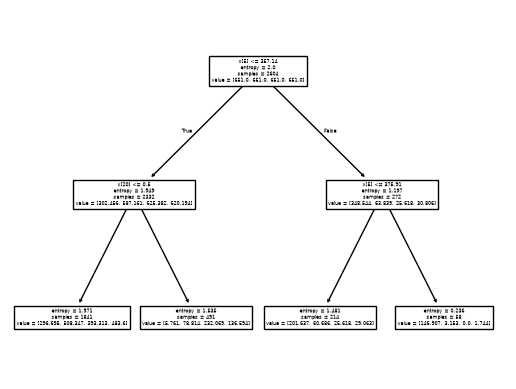

In [31]:
tree.plot_tree(clf)

In [32]:
from sklearn.metrics import f1_score

def get_acc_scores(clf, train_X, train_y, val_X, val_y):
    train_pred = clf.predict(train_X)
    val_pred = clf.predict(val_X)
    
    train_acc = f1_score(train_y, train_pred, average='macro')
    val_acc = f1_score(val_y, val_pred, average='macro')
    
    return train_acc, val_acc

In [33]:
train_acc, val_acc = get_acc_scores(clf,train_X, train_y, val_X, val_y)
print("Train f1 score: {:.3f}".format(train_acc))
print("Validation f1 score: {:.3f}".format(val_acc))

Train f1 score: 0.326
Validation f1 score: 0.311


In [34]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'max_depth': np.arange(2, 400, 50),
    'min_samples_split': np.arange(2, 50, 5)
}

dt_clf = tree.DecisionTreeClassifier(
    criterion='entropy',
    class_weight='balanced'
)

grid_clf = GridSearchCV(
    dt_clf,
    parameters,
    scoring='f1_macro'
)

grid_clf.fit(train_X, train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ion='entropy')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 2, ...52, 302, 352]), 'min_samples_split': array([ 2, 7..., 37, 42, 47])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, d

In [35]:
pd.DataFrame(grid_clf.cv_results_)

print(grid_clf.best_score_)

print(grid_clf.best_params_)

clf = grid_clf.best_estimator_

train_acc, val_acc = get_acc_scores(clf, train_X, train_y, val_X, val_y)

print("Train f1 score: {:.3f}".format(train_acc))
print("Validation f1 score: {:.3f}".format(val_acc))

0.3450672851453754
{'max_depth': np.int64(302), 'min_samples_split': np.int64(2)}
Train f1 score: 1.000
Validation f1 score: 0.317


train score of 1.000? crazy. overfitted.

In [36]:
clf = tree.DecisionTreeClassifier(class_weight='balanced')
path = clf.cost_complexity_pruning_path(train_X, train_y)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [37]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha, class_weight='balanced')
    clf.fit(train_X, train_y)
    clfs.append(clf)

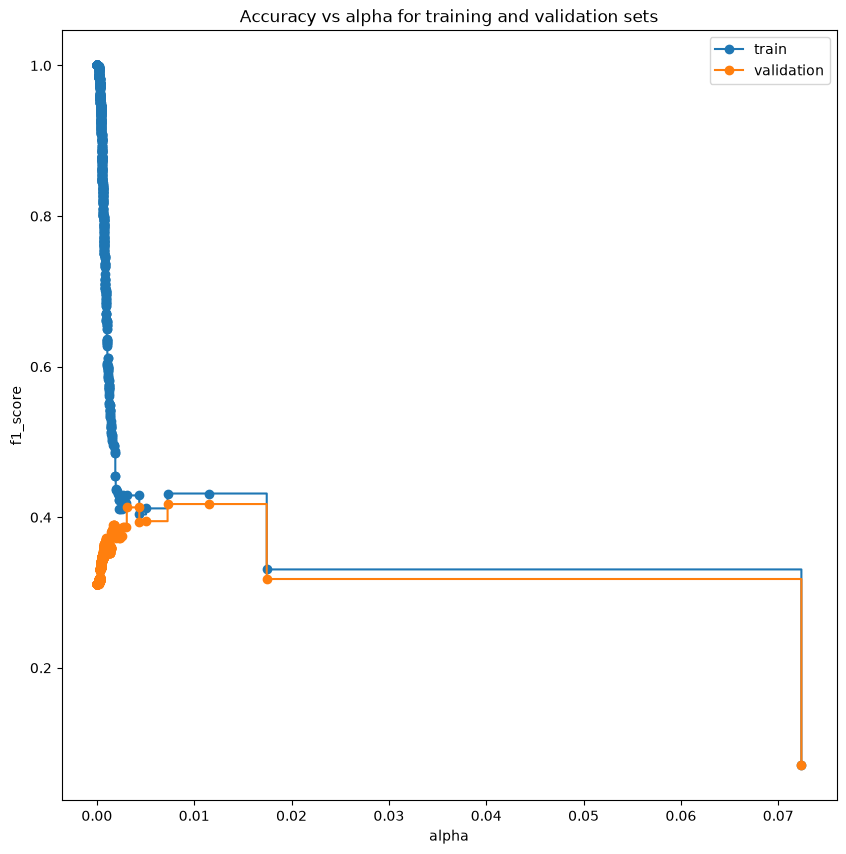

In [38]:
train_scores = [f1_score(train_y, clf.predict(train_X), average='macro') for clf in clfs]
val_scores = [f1_score(val_y, clf.predict(val_X), average='macro') for clf in clfs]

fig, ax = plt.subplots(figsize=(10,10))
ax.set_xlabel("alpha")
ax.set_ylabel("f1_score")
ax.set_title("Accuracy vs alpha for training and validation sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, val_scores, marker='o', label="validation",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [39]:
best_index = np.argmax(val_scores)

print("Best alpha:", ccp_alphas[best_index])
print("Train F1:", train_scores[best_index])
print("Validation F1:", val_scores[best_index])

Best alpha: 0.0072669784327422104
Train F1: 0.43153006441160546
Validation F1: 0.41754970558632587


Initial decision tree with a max depth of 2 achieved a training macro-F1 of 0.326 and validation macro-F1 of 0.311, indicating underfitting. Hyperparameter grid search produced a more complex tree that achieved a training macro-F1 of 1.0 but 0.315 on validation, indicating severe overfitting. Cost complexity pruning improved generalisation. The best pruning value was ccp_alpha = 0.00727, which produced a training macro-F1 of 0.432 and validation macro-F1 of 0.418. This suggests the reducing complexity reduced overfitting.



In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train_X)

train_X = scaler.transform(train_X)
val_X = scaler.transform(val_X)
test_X = scaler.transform(test_X)

In [41]:
from sklearn.svm import SVC

clf = SVC(
  kernel='linear',
  C=1.0,
  random_state=0
)

clf.fit(train_X, train_y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [42]:
from sklearn.metrics import f1_score

def get_f1_scores(clf, train_x, train_y, val_x, val_y):
  train_pred = clf.predict(train_x)
  val_pred = clf.predict(val_x)
  train_f1 = f1_score(train_y, train_pred, average='macro')
  val_f1 = f1_score(val_y, val_pred, average='macro')
  return train_f1, val_f1

In [43]:
train_f1, val_f1 = get_f1_scores(
  clf, train_X, train_y, val_X, val_y
)
print("Train F1-Score: {:.3f}".format(train_f1))
print("Validation F1-Score: {:.3f}".format(val_f1))

Train F1-Score: 0.343
Validation F1-Score: 0.303


In [44]:
kernels = ['linear', 'poly', 'rbf']
train_performance = list()
valid_performance = list()

for kernel in kernels:
  clf = SVC(
    kernel=kernel,
    C=1.0,
    random_state=0
  ).fit(train_X, train_y)
  
  train_f1, val_f1 = get_f1_scores(
    clf, train_X, train_y, val_X, val_y
  )
  
  train_performance.append(train_f1)
  valid_performance.append(val_f1)

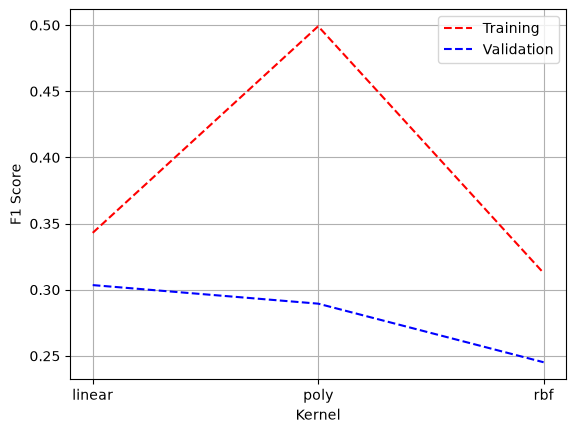

In [45]:
plt.plot(kernels, train_performance, 'r--')
plt.plot(kernels, valid_performance, 'b--')
plt.ylabel('F1 Score')
plt.xlabel('Kernel')
plt.legend(['Training', 'Validation'])
plt.grid()
plt.show()

In [46]:
lambda_params = np.logspace(-5, 1, num=25)
train_performance = list()
valid_performance = list()

for lambda_param in lambda_params:
  clf = SVC(
    kernel='rbf',
    C=1.0/lambda_param,
    random_state=0
  ).fit(train_X, train_y)
  
  train_f1, val_f1 = get_f1_scores(
    clf, train_X, train_y, val_X, val_y
  )
  
  train_performance.append(train_f1)
  valid_performance.append(val_f1)

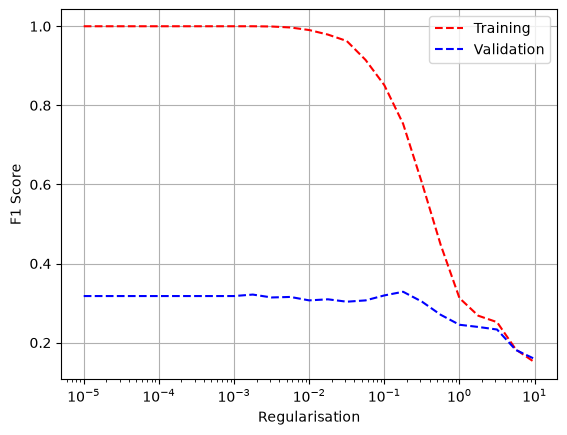

In [47]:
plt.plot(lambda_params, train_performance, 'r--')
plt.plot(lambda_params, valid_performance, 'b--')

plt.ylabel('F1 Score')
plt.xlabel('Regularisation')
plt.legend(['Training', 'Validation'])
plt.grid()
plt.xscale("log")
plt.show()

In [48]:
best_index = np.argmax(valid_performance)

print("Best lambda:", lambda_params[best_index])
print("Best C:", 1 / lambda_params[best_index])
print("Train F1:", train_performance[best_index])
print("Validation F1:", valid_performance[best_index])

Best lambda: 0.1778279410038923
Best C: 5.62341325190349
Train F1: 0.7534461052140075
Validation F1: 0.3286127837171663


In [49]:
gamma_params = np.logspace(-5, 1, num=25)
train_performance = list()
valid_performance = list()

for gamma_param in gamma_params:
    clf = SVC(
        kernel='rbf',
        C=5.62341325190349,
        gamma=gamma_param,
        random_state=0
    ).fit(train_X, train_y)

    train_f1, val_f1 = get_f1_scores(
        clf, train_X, train_y, val_X, val_y
    )

    train_performance.append(train_f1)
    valid_performance.append(val_f1)

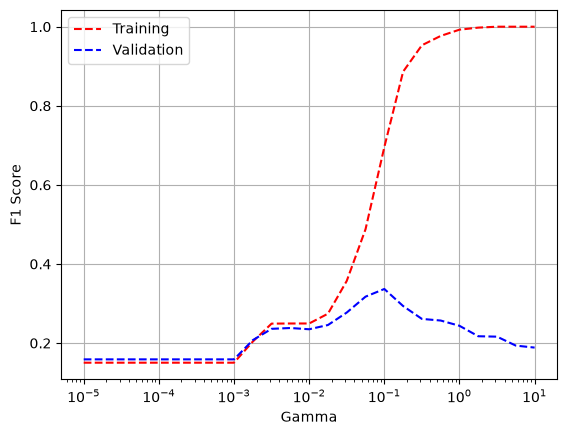

In [50]:
plt.plot(gamma_params, train_performance, 'r--')
plt.plot(gamma_params, valid_performance, 'b--')

plt.ylabel('F1 Score')
plt.xlabel('Gamma')
plt.legend(['Training', 'Validation'])
plt.grid()
plt.xscale("log")
plt.show()

In [51]:
best_index = np.argmax(valid_performance)

print("Best gamma:", gamma_params[best_index])
print("Train F1:", train_performance[best_index])
print("Validation F1:", valid_performance[best_index])

Best gamma: 0.1
Train F1: 0.6954690310513947
Validation F1: 0.3367731222074774


In [52]:
clf = SVC(
    kernel='rbf',
    C=5.62341325190349,
    gamma=0.1,
    random_state=0
).fit(train_X, train_y)

In [53]:
from sklearn.metrics import classification_report

test_pred = clf.predict(test_X)

print(classification_report(test_y, test_pred))

              precision    recall  f1-score   support

     Extreme       0.58      0.18      0.28        83
        High       0.36      0.40      0.38       264
         Low       0.25      0.14      0.18       124
    Moderate       0.50      0.60      0.55       397

    accuracy                           0.44       868
   macro avg       0.42      0.33      0.34       868
weighted avg       0.43      0.44      0.42       868



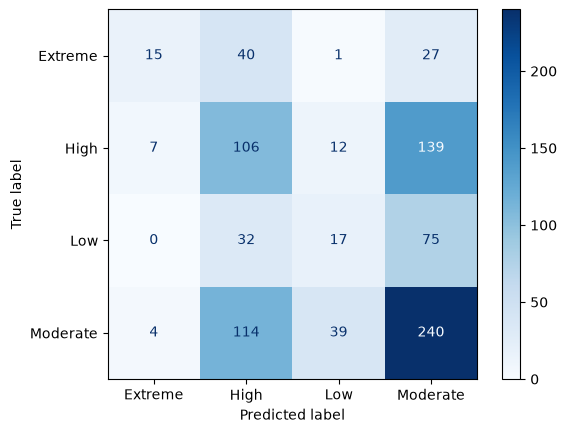

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    clf,
    test_X,
    test_y,
    cmap=plt.cm.Blues
)

plt.show()

In [55]:
import torch.nn as nn

class NeuNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_classes):
        super(NeuNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_classes)
        
    def forward(self, x):
        x = self.fc1(x)
#         x = torch.sigmoid(x) 
        x = torch.relu(x)
        x = self.fc2(x)
        return x

INPUT_DIM = train_X.shape[1]
HIDDEN_LAYER_DIM = 64
OUTPUT_CLASSES = 4

model = NeuNet(INPUT_DIM, HIDDEN_LAYER_DIM, OUTPUT_CLASSES)

In [57]:
import torch.optim as optim
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [58]:
label_names = {
    0: 'Extreme',
    1: 'High',
    2: 'Low',
    3: 'Moderate'
}

label_to_int = {
    'Extreme': 0,
    'High': 1,
    'Low': 2,
    'Moderate': 3
}

nn_train_y = train_y.map(label_to_int).to_numpy()
nn_val_y = val_y.map(label_to_int).to_numpy()
nn_test_y = test_y.map(label_to_int).to_numpy()

In [59]:


nn_train_X = torch.FloatTensor(train_X)
nn_train_y = torch.LongTensor(nn_train_y)

nn_val_X = torch.FloatTensor(val_X)
nn_val_y = torch.LongTensor(nn_val_y)

nn_test_X = torch.FloatTensor(test_X)
nn_test_y = torch.LongTensor(nn_test_y)

/tmp/ipykernel_15078/1250384074.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  nn_train_y = torch.LongTensor(nn_train_y)


In [60]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    return train_loss, train_acc

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    return val_loss, val_acc

In [61]:
from torch.utils.data import Dataset, DataLoader
import torch

class WildFireDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 32

train_dataset = WildFireDataset(nn_train_X, nn_train_y)
val_dataset = WildFireDataset(nn_val_X, nn_val_y)
test_dataset = WildFireDataset(nn_test_X, nn_test_y)

train_generator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_generator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_generator = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [62]:
epochs = 200
history = {
    'loss': [], 'val_loss': [],
    'categorical_accuracy': [], 'val_categorical_accuracy': []
}

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_generator, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, validation_generator, criterion, device)

    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['categorical_accuracy'].append(train_acc)
    history['val_categorical_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

print("Training complete!")

Epoch 1/200: Loss: 1.3378, Val Loss: 1.3030, Train Acc: 0.3856, Val Acc: 0.4712
Epoch 2/200: Loss: 1.2845, Val Loss: 1.2635, Train Acc: 0.4293, Val Acc: 0.4643
Epoch 3/200: Loss: 1.2570, Val Loss: 1.2432, Train Acc: 0.4301, Val Acc: 0.4666
Epoch 4/200: Loss: 1.2434, Val Loss: 1.2335, Train Acc: 0.4309, Val Acc: 0.4654
Epoch 5/200: Loss: 1.2354, Val Loss: 1.2284, Train Acc: 0.4305, Val Acc: 0.4654
Epoch 6/200: Loss: 1.2325, Val Loss: 1.2258, Train Acc: 0.4301, Val Acc: 0.4654
Epoch 7/200: Loss: 1.2284, Val Loss: 1.2248, Train Acc: 0.4305, Val Acc: 0.4666
Epoch 8/200: Loss: 1.2278, Val Loss: 1.2223, Train Acc: 0.4301, Val Acc: 0.4666
Epoch 9/200: Loss: 1.2259, Val Loss: 1.2204, Train Acc: 0.4309, Val Acc: 0.4643
Epoch 10/200: Loss: 1.2215, Val Loss: 1.2190, Train Acc: 0.4305, Val Acc: 0.4631
Epoch 11/200: Loss: 1.2196, Val Loss: 1.2168, Train Acc: 0.4316, Val Acc: 0.4631
Epoch 12/200: Loss: 1.2182, Val Loss: 1.2155, Train Acc: 0.4301, Val Acc: 0.4643
Epoch 13/200: Loss: 1.2165, Val Loss:

In [63]:
import matplotlib.pyplot as plt
def plot_learning_curve(train_loss, val_loss, train_metric, val_metric, metric_name='Accuracy'):
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.plot(train_loss, 'b--')
    plt.plot(val_loss, 'r--')
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(train_metric, 'b--')
    plt.plot(val_metric, 'r--')
    plt.xlabel("epochs")
    plt.ylabel(metric_name)
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid()
    
    plt.show()

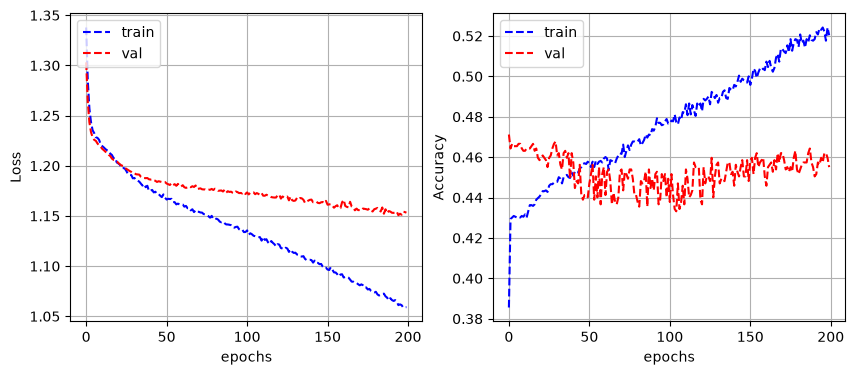

In [64]:
plot_learning_curve(
    history['loss'],
    history['val_loss'],
    history['categorical_accuracy'],
    history['val_categorical_accuracy'],
    metric_name='Accuracy'
)

what does this mean? left graph is loss, lower is better. right is accuracy, higher is better.
Loss
Blue Training - Falls from about 1.35 to 1.06 ish. 
Red Validation - Falls initially, then improves slowly to about 1.15.
Accuracy
Blue Training - Keeps climbing froma bout 0.43 to about 0.52. 
Red Validation - Doesn't really improve, hovers around 0.45

smells like overfitting. 

In [66]:
from sklearn.metrics import f1_score, classification_report

label_names = {
    0: 'Extreme',
    1: 'High',
    2: 'Low',
    3: 'Moderate'
}

model.eval()

nn_test_X = nn_test_X.to(device)
nn_test_y = nn_test_y.to(device)

with torch.no_grad():
    outputs = model(nn_test_X)
    test_loss = criterion(outputs, nn_test_y).item()
    _, predicted = torch.max(outputs, 1)

pred_y = predicted.cpu().numpy()
true_y = nn_test_y.cpu().numpy()

test_acc = (pred_y == true_y).mean()
macro_f1 = f1_score(true_y, pred_y, average='macro')

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Macro F1 Score : {macro_f1:.4f}")
print()
print("Classification Report:")
print(
    classification_report(
        true_y,
        pred_y,
        target_names=list(label_names.values())
    )
)

Test Loss : 1.1638
Test Accuracy : 0.4551
Macro F1 Score : 0.3194

Classification Report:
              precision    recall  f1-score   support

     Extreme       0.70      0.08      0.15        83
        High       0.36      0.41      0.38       264
         Low       0.41      0.10      0.17       124
    Moderate       0.51      0.68      0.58       397

    accuracy                           0.46       868
   macro avg       0.49      0.32      0.32       868
weighted avg       0.47      0.46      0.42       868



Drastically leans toward common classes such as moderate, while less common such as extreme are tiny.

In [69]:
learning_rates = [0.001, 0.01, 0.1]
lr_results = {}

from sklearn.metrics import f1_score

def get_nn_f1(model, X, y, device):
    model.eval()

    with torch.no_grad():
        outputs = model(X.to(device))
        _, predicted = torch.max(outputs, 1)

    pred_y = predicted.cpu().numpy()
    true_y = y.cpu().numpy()

    return f1_score(true_y, pred_y, average='macro')

for lr in learning_rates:
    torch.manual_seed(0)
    model = NeuNet(
        INPUT_DIM,
        HIDDEN_LAYER_DIM,
        OUTPUT_CLASSES
    ).to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_generator, criterion, optimizer, device
        )
        val_loss, val_acc = validate_epoch(
            model, validation_generator, criterion, device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
    val_f1 = get_nn_f1(model, nn_val_X, nn_val_y, device)
    
    lr_results[lr] = {
        'loss': train_losses,
        'val_loss': val_losses,
        'accuracy': train_accs,
        'val_accuracy': val_accs,
        'val_f1': val_f1
    }
    

    print(
        f"lr={lr}: "
        f"train loss={train_losses[-1]:.4f}, "
        f"val loss={val_losses[-1]:.4f}, "
        f"train acc={train_accs[-1]:.4f}, "
        f"val acc={val_accs[-1]:.4f}, "
        f"val f1={val_f1:.4f}"
    )

lr=0.001: train loss=1.2099, val loss=1.2079, train acc=0.4405, val acc=0.4631, val f1=0.1934
lr=0.01: train loss=1.0555, val loss=1.1400, train acc=0.5242, val acc=0.4654, val f1=0.3407
lr=0.1: train loss=0.4551, val loss=2.2750, train acc=0.8157, val acc=0.3306, val f1=0.3130


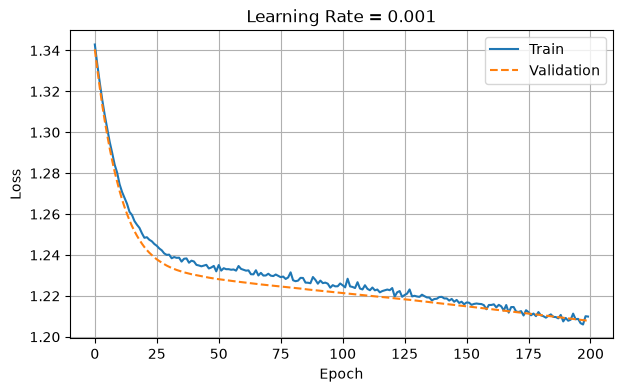

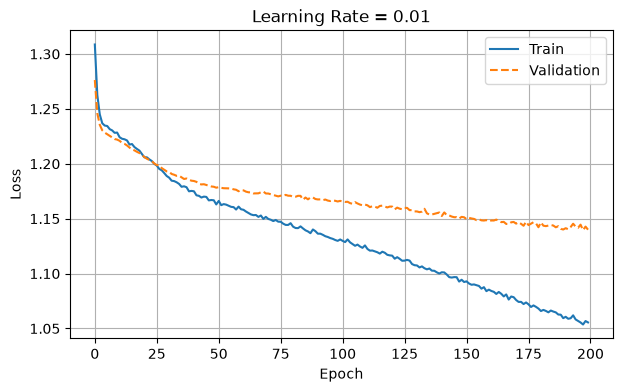

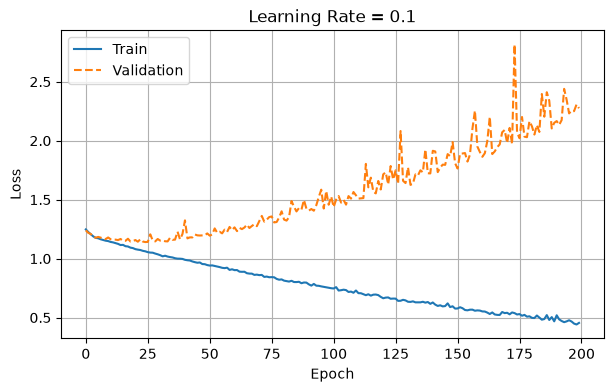

In [71]:
for lr in learning_rates:
    plt.figure(figsize=(7, 4))

    plt.plot(
        lr_results[lr]['loss'],
        label='Train'
    )
    plt.plot(
        lr_results[lr]['val_loss'],
        '--',
        label='Validation'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Learning Rate = {lr}')
    plt.legend()
    plt.grid()
    plt.show()

0.001 = Too slow
0.01 = Potentially
0.1 = Overfitted

In [74]:
learning_rates = [0.005, 0.01, 0.03]
lr_results = {}
epochs = 100

from sklearn.metrics import f1_score

def get_nn_f1(model, X, y, device):
    model.eval()

    with torch.no_grad():
        outputs = model(X.to(device))
        _, predicted = torch.max(outputs, 1)

    pred_y = predicted.cpu().numpy()
    true_y = y.cpu().numpy()

    return f1_score(true_y, pred_y, average='macro')

for lr in learning_rates:
    torch.manual_seed(0)
    model = NeuNet(
        INPUT_DIM,
        HIDDEN_LAYER_DIM,
        OUTPUT_CLASSES
    ).to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_generator, criterion, optimizer, device
        )
        val_loss, val_acc = validate_epoch(
            model, validation_generator, criterion, device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
    val_f1 = get_nn_f1(model, nn_val_X, nn_val_y, device)
    
    lr_results[lr] = {
        'loss': train_losses,
        'val_loss': val_losses,
        'accuracy': train_accs,
        'val_accuracy': val_accs,
        'val_f1': val_f1
    }
    

    print(
        f"lr={lr}: "
        f"train loss={train_losses[-1]:.4f}, "
        f"val loss={val_losses[-1]:.4f}, "
        f"train acc={train_accs[-1]:.4f}, "
        f"val acc={val_accs[-1]:.4f}, "
        f"val f1={val_f1:.4f}"
    )

lr=0.005: train loss=1.1647, val loss=1.1793, train acc=0.4581, val acc=0.4493, val f1=0.2442
lr=0.01: train loss=1.1311, val loss=1.1662, train acc=0.4785, val acc=0.4447, val f1=0.2639


KeyboardInterrupt: 

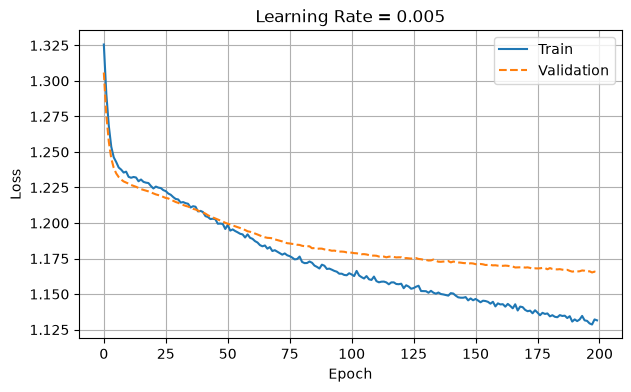

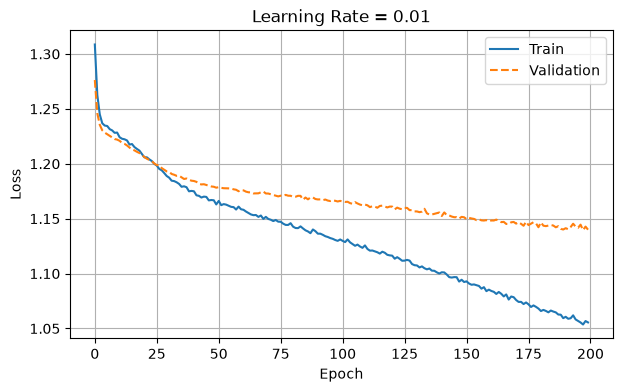

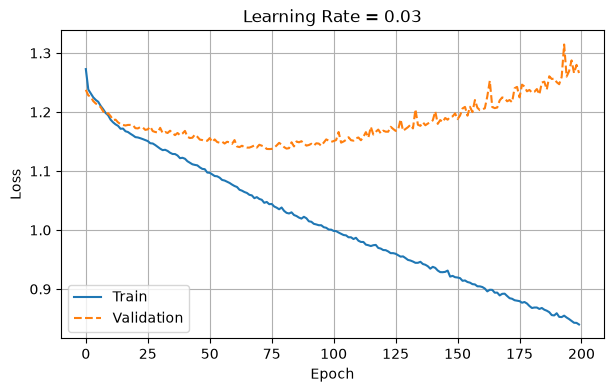

In [73]:
for lr in learning_rates:
    plt.figure(figsize=(7, 4))

    plt.plot(
        lr_results[lr]['loss'],
        label='Train'
    )
    plt.plot(
        lr_results[lr]['val_loss'],
        '--',
        label='Validation'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Learning Rate = {lr}')
    plt.legend()
    plt.grid()
    plt.show()

0.03 has the highest macro-F1 but the ugliest loss curve. It might be a good learning rate but maybe 200 epochs are too many.

In [75]:
learning_rates = [0.005, 0.01, 0.03]
lr_results = {}

from sklearn.metrics import f1_score

def get_nn_f1(model, X, y, device):
    model.eval()

    with torch.no_grad():
        outputs = model(X.to(device))
        _, predicted = torch.max(outputs, 1)

    pred_y = predicted.cpu().numpy()
    true_y = y.cpu().numpy()

    return f1_score(true_y, pred_y, average='macro')

for lr in learning_rates:
    torch.manual_seed(0)
    model = NeuNet(
        INPUT_DIM,
        HIDDEN_LAYER_DIM,
        OUTPUT_CLASSES
    ).to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_generator, criterion, optimizer, device
        )
        val_loss, val_acc = validate_epoch(
            model, validation_generator, criterion, device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
    val_f1 = get_nn_f1(model, nn_val_X, nn_val_y, device)
    
    lr_results[lr] = {
        'loss': train_losses,
        'val_loss': val_losses,
        'accuracy': train_accs,
        'val_accuracy': val_accs,
        'val_f1': val_f1
    }
    

    print(
        f"lr={lr}: "
        f"train loss={train_losses[-1]:.4f}, "
        f"val loss={val_losses[-1]:.4f}, "
        f"train acc={train_accs[-1]:.4f}, "
        f"val acc={val_accs[-1]:.4f}, "
        f"val f1={val_f1:.4f}"
    )

lr=0.005: train loss=1.1647, val loss=1.1793, train acc=0.4581, val acc=0.4493, val f1=0.2442
lr=0.01: train loss=1.1311, val loss=1.1662, train acc=0.4785, val acc=0.4447, val f1=0.2639
lr=0.03: train loss=1.0006, val loss=1.1494, train acc=0.5580, val acc=0.4493, val f1=0.3561


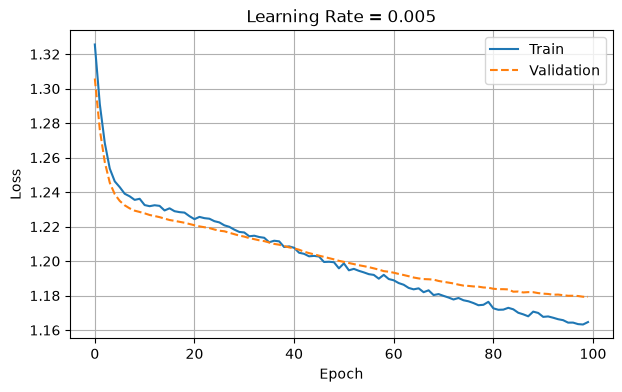

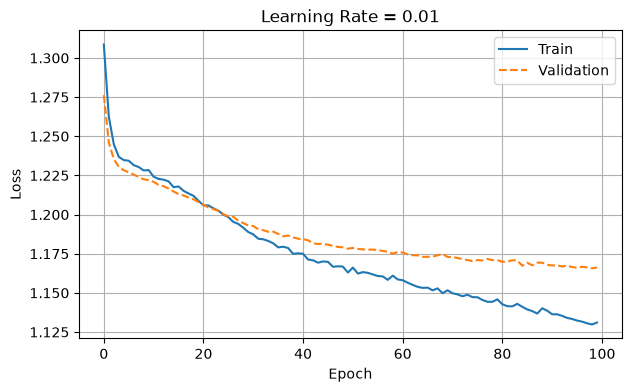

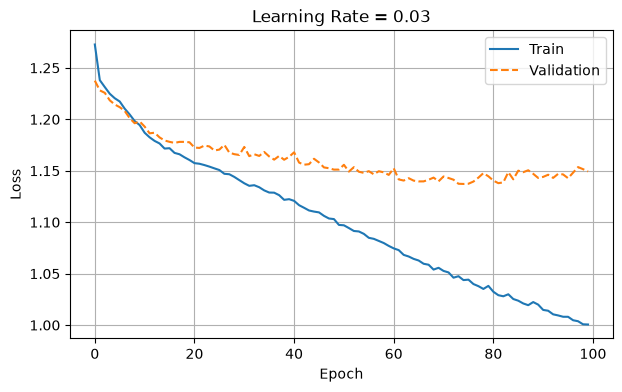

In [76]:
for lr in learning_rates:
    plt.figure(figsize=(7, 4))

    plt.plot(
        lr_results[lr]['loss'],
        label='Train'
    )
    plt.plot(
        lr_results[lr]['val_loss'],
        '--',
        label='Validation'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Learning Rate = {lr}')
    plt.legend()
    plt.grid()
    plt.show()

I'm liking 0.03 the most with epoch count at 100, it has highest validation loss (1.1494) and best macro_F1 by a large margin (0.3561). But higher epoch count causes training loss to drop strongly. So we should probably try and find the best stopping point.

In [77]:
import copy

torch.manual_seed(0)

model = NeuNet(
    INPUT_DIM,
    HIDDEN_LAYER_DIM,
    OUTPUT_CLASSES
).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.03)

epochs = 200
patience = 10

best_val_loss = float('inf')
best_model = None
best_epoch = 0
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(
        model, train_generator, criterion, optimizer, device
    )

    val_loss, val_acc = validate_epoch(
        model, validation_generator, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

model.load_state_dict(best_model)

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")

Early stopping at epoch 85
Best epoch: 75
Best validation loss: 1.1372


In [78]:
val_f1 = get_nn_f1(model, nn_val_X, nn_val_y, device)
print(f"Validation F1: {val_f1:.4f}")

Validation F1: 0.3493


100 epochs was a good guess! Training stopped at epoch 85, minimum validation loss of 1.1372 at epoch 75. Let's find another hyperparameter. Hidden-layer size, maybe.

In [79]:
import copy

hidden_dims = [32, 64, 128]

for hidden_dim in hidden_dims:
    torch.manual_seed(0)

    model = NeuNet(
        INPUT_DIM,
        hidden_dim,
        OUTPUT_CLASSES
    ).to(device)

    optimizer = optim.SGD(model.parameters(), lr=0.03)

    epochs = 200
    patience = 10

    best_val_loss = float('inf')
    best_model = None
    best_epoch = 0
    epochs_without_improvement = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_generator, criterion, optimizer, device
        )

        val_loss, val_acc = validate_epoch(
            model, validation_generator, criterion, device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_model)

    val_f1 = get_nn_f1(
        model, nn_val_X, nn_val_y, device
    )

    print(
        f"Hidden dim={hidden_dim}: "
        f"best epoch={best_epoch}, "
        f"val loss={best_val_loss:.4f}, "
        f"val F1={val_f1:.4f}"
    )

Hidden dim=32: best epoch=73, val loss=1.1397, val F1=0.3091
Hidden dim=64: best epoch=75, val loss=1.1372, val F1=0.3493
Hidden dim=128: best epoch=79, val loss=1.1427, val F1=0.3361


Improvement is okay, best is hidden dim at 64. val loss = 1.1372, val_f1 = 0.3493

In [80]:
torch.manual_seed(0)

model = NeuNet(
    INPUT_DIM,
    64,
    OUTPUT_CLASSES
).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.03)

epochs = 200
patience = 10

best_val_loss = float('inf')
best_model = None
best_epoch = 0
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(
        model, train_generator, criterion, optimizer, device
    )

    val_loss, val_acc = validate_epoch(
        model, validation_generator, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        break

model.load_state_dict(best_model)

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")

Best epoch: 75
Best validation loss: 1.1372


In [81]:
model.eval()

with torch.no_grad():
    outputs = model(nn_test_X.to(device))
    test_loss = criterion(outputs, nn_test_y.to(device))

    _, predicted = torch.max(outputs, 1)

pred_y = predicted.cpu().numpy()
true_y = nn_test_y.cpu().numpy()

test_f1 = f1_score(
    true_y,
    pred_y,
    average='macro'
)

test_accuracy = (pred_y == true_y).mean()

print(f"Test Loss: {test_loss.item():.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")

print(classification_report(
    true_y,
    pred_y,
    target_names=[
        'Extreme',
        'High',
        'Low',
        'Moderate'
    ]
))

Test Loss: 1.1630
Test Accuracy: 0.4724
Macro F1 Score: 0.3531
              precision    recall  f1-score   support

     Extreme       0.71      0.18      0.29        83
        High       0.39      0.33      0.36       264
         Low       0.31      0.11      0.17       124
    Moderate       0.51      0.74      0.60       397

    accuracy                           0.47       868
   macro avg       0.48      0.34      0.35       868
weighted avg       0.46      0.47      0.43       868



Ultimately, the neural network I selected uses 64 hidden neurons, a learning rate of 0.03, and an early stopping with a patience of 10 epochs. The best model occured at epoch 75 with validation loss of 
1.1372. On the held out model test, model achieved an accuracy of 0.4724 and macro-F1 score of 0.3531.

